# STEP 11. 최종 결과 GeoJSON 내보내기 (네트워크 정의별)

**목적**: "이 네트워크 정의에서 이 공원은 어느 묶음에 속하는가"를 GIS에서 바로 쓸 수 있도록, 정의별 GeoJSON으로 정리한다. 재계산은 하지 않고 STEP 6–10 결과만 모은다.

| 레이어 | 파일 | 피처 |
|---|---|---|
| 공원 | `parks_{정의}.geojson` | 공원(선형 공원 구간 포함) 1개 = 1 피처, 묶음 id·고립 지수·상태 |
| 묶음 | `groups_{정의}.geojson` | 묶음 1개 = 1 피처, 구성 공원의 볼록껍질 + 요약 |
| 연결 | `edges_{정의}.geojson` | 공원 쌍 1개 = 1 피처, 대표점을 잇는 **직선**(실제 보행 경로가 아님) + 관계 속성 |

정의(연구 개요 RQ3):
- **D** walking distance(근접성 기준선)
- **N1** directional change(적게 꺾는 길, γ = 1/2/4)
- **N2** street-axis continuity(같은 연속 가로)
- **N3** excess field overlap

보조 정의 **N1rel**(상대 기준)과 **N1knn**(상호 k-최근접)은 비교용이다.

**묶음 = configurational 합의 묶음 ∩ 도보 10분 지름**: 모든 묶음은 STEP 10에서 구성원 **모든 쌍이 서로 도보 10분(보행망 최단거리 800 m) 이내**가 되도록 분할했다. 분할 전 묶음 id는 `*_nolimit` 열에 함께 둔다.

모든 파일은 EPSG:4326(RFC 7946)이다. 출력 폴더는 `outputs/{AREA}/geojson/`이고, 데이터 사전은 `README.md`에 있다.

In [1]:
# ===== 공통 설정 (모든 STEP 노트북에서 동일) =====
import os
import json
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)

# 분석 지역: "Brooklyn"(파일럿) 또는 "NYC"(전체). 환경변수 PARK_STUDY_AREA로도 지정 가능.
STUDY_AREA = os.environ.get("PARK_STUDY_AREA", "Brooklyn")

ROOT = Path.cwd()
DATA = ROOT / "Data"
PARKS_PATH = DATA / "NYCPark" / "Parks_Properties_20260923.geojson"
NET_DIR = DATA / "derived" / "network"        # STEP1 결과 (지역 무관, NYC+버퍼 전체)
AREA_DIR = DATA / "derived" / STUDY_AREA      # STEP2 이후 결과
OUT_DIR = ROOT / "outputs" / STUDY_AREA
for _d in (NET_DIR, AREA_DIR, OUT_DIR):
    _d.mkdir(parents=True, exist_ok=True)

CRS = 32618            # UTM 18N (m)
R_MAX = 3200           # 탐색 한계 (m) = 보로 네트워크 버퍼 폭
SPEED = 1.0            # speed_m_s=1 -> agg_seconds == 경로 길이(m)

BOROUGHS = {"M": "Manhattan", "X": "Bronx", "B": "Brooklyn", "Q": "Queens", "R": "Staten Island"}
AREA_BOROUGHS = ["B"] if STUDY_AREA == "Brooklyn" else list(BOROUGHS)

# 네트워크 변형: C = 가로 중심선 + 보행전용 경로 (주 분석), S = 보도 포함 전체 보행망 (민감도)
VARIANTS = ["C", "S"]
PRIMARY = "C"
SIDEWALK_FOOTWAYS = {"sidewalk", "crossing", "traffic_island"}

# 공원 필터 (사용자 결정): Flagship + 비공원성 필지 제외, 면적 상한 100 acres (계산은 200 상위집합)
EXCLUDE_TYPES = ["Flagship Park", "Operations", "Lot", "Undeveloped",
                 "Buildings/Institutions", "Cemetery", "Managed Sites"]
AREA_CAP = 100
AREA_CAP_SUPERSET = 200
AREA_CAP_GRID = [50, 100, 200]
RESTRICTED_TYPES = ["Garden", "Jointly Operated Playground"]            # 접근 제한 민감도
STREET_EMBEDDED_TYPES = ["Triangle/Plaza", "Strip", "Mall", "Parkway"]  # 가로 매몰형 민감도

# 공원-네트워크 attachment
ATTACH_BUFFER = {"C": 20.0, "S": 10.0}   # 경계 버퍼 (m): C는 중심선이 도로 폭 절반만큼 떨어져 있음
ATTACH_BUFFER_GRID = {"C": [15.0, 20.0, 30.0], "S": [5.0, 10.0, 20.0]}
INSIDE_SHARE = 0.9       # 공원 내부에 90% 이상 들어간 세그먼트는 attachment에서 제외 (통행은 허용)
K_SOURCES = 8            # 공원당 출발 attachment 최대 개수 (farthest-point sampling)
SMALL_COMPONENT = 200    # 이보다 작은 연결요소에만 붙은 공원은 'unresolved'

# 최종 묶음 공통 절차: 설정별 Louvain(γ) → 보로 단위 퍼콜레이션 필터 → 합의 ≥ 0.5 → 도보 10분 지름 분할
MAIN_GAMMA = 2
COMMERCIAL_BUFFER = 100   # 연구 개요: 군집 구성 공원 주변 100 m = 상업 영역

# 묶음 크기 제약: 묶음 안 모든 공원 쌍이 서로 도보 10분 이내 (보행망 최단거리, 1.33 m/s × 600 s ≈ 800 m)
WALK_LIMIT = 800
WALK_LIMIT_GRID = [400, 800, 1200]   # 5 / 10 / 15분 민감도

# N1 angular few-turn
N1_THETAS = [15, 45, 90, 180]
N1_RADII = [800, 1600, 3200]
N1_REL_Q = [0.1, 0.2]
DIST_BANDS = [0, 200, 400, 800, 1600, 3200]

# D walking distance (근접성 기준선): 보행망 최단거리 ≤ d 이면 연결
D_DISTS = [200, 400, 800]

# N2 street-axis continuity: 같은 연속 가로(stroke) 위, 두 공원 구간 사이 간격 ≤ lim
N2_ALONG = [400, 800, 1600]
# (큰길 속성 계산용) 각도 choice/NACH 반경과 상위 비율
N2_RADII = [800, 1600, 3200]
N2_TOP_P = [0.02, 0.05, 0.10]
STROKE_ANGLE = 30
STROKE_ANGLE_GRID = [20, 30, 45]
N2_MAX_ALONG = [3200, None]

# N3 excess few-turn field overlap
N3_THETAS = [45, 90]
N3_RADII = [800, 1600]
N3_TAU = [0.1, 0.2]
N3_KAPPA = [1.0, 1.25]

print(f"STUDY_AREA={STUDY_AREA}  boroughs={AREA_BOROUGHS}  AREA_DIR={AREA_DIR.relative_to(ROOT)}")

STUDY_AREA=NYC  boroughs=['M', 'X', 'B', 'Q', 'R']  AREA_DIR=Data/derived/NYC


In [2]:
import shutil
from scipy.spatial.distance import pdist
from shapely.geometry import LineString
import matplotlib.pyplot as plt

GR_DIR = AREA_DIR / "graphs"
RG_DIR = AREA_DIR / "regroup"
GJ_DIR = OUT_DIR / "geojson"
if GJ_DIR.exists():
    shutil.rmtree(GJ_DIR)
GJ_DIR.mkdir(parents=True)
DEF_CFG = f"d{int(ATTACH_BUFFER[PRIMARY])}_K{K_SOURCES}"
PERC_MAX = 0.5

final = pd.read_csv(OUT_DIR / "regroup" / "park_groups_final.csv", index_col="park_id")
PIDS = final.index.tolist()
pid_set = set(PIDS)
parks = gpd.read_parquet(NET_DIR / "parks.parquet").loc[PIDS]
RG = {d: pd.read_parquet(AREA_DIR / f"robust_groups_{d}.parquet").reindex(PIDS) for d in ["D", "N1abs", "N1rel", "N2", "N3"]}
PT = parks.geometry.representative_point()

# 공원 쌍 보행망 최단거리 (대칭 최솟값; 3.2 km 밖은 없음)
pp = pd.read_parquet(AREA_DIR / f"pairs_{PRIMARY}.parquet")
pp = pp[(pp.cfg == DEF_CFG) & pp.i.isin(pid_set) & pp.j.isin(pid_set)]
pp = pp.assign(a=np.minimum(pp.i, pp.j), b=np.maximum(pp.i, pp.j)).groupby(["a", "b"])[
    ["A_800", "A_1600", "A_3200", "D_net"]].min()
DNET = pp["D_net"].dropna().to_dict()


def walk_dist(x, y):
    return 0.0 if x == y else DNET.get((x, y) if x < y else (y, x), np.inf)
print(f"{STUDY_AREA}: {len(PIDS):,} park features ({int(parks.is_piece.sum())} linear-park pieces)")

NYC: 2,057 park features (180 linear-park pieces)


## 11-1. 공통 함수: 묶음 id, 상태, 공원 레이어
- **묶음 id**: 정의 접두사 + 3자리 순번. 크기가 큰 묶음부터 번호를 매기고, 크기가 같으면 가장 작은 `park_id` 순이다. 예: `N1g2-001`은 N1(γ=2)에서 가장 큰 묶음.
- **status** 판정 순서:
  1. `unresolved`: 공원의 네트워크 attachment가 작은 연결요소뿐이라 판정 불가(OSM 누락 가능성)
  2. `robust_isolated`: IsolationPersistence ≥ 0.8
  3. `grouped`: 도보 10분 제약을 만족하는 강건 묶음에 소속
  4. `beyond_walk_limit`: configurational 합의 묶음에는 속하지만 10분 안에 함께 묶일 공원이 없음
  5. `unstable`: 그 외(설정에 따라 연결 여부가 바뀜)

In [3]:
def relabel(labels, prefix):
    """정수 묶음 라벨(-1 = 없음) → 'PREFIX-001' 형식. 크기 내림차순, 동점은 최소 park_id 순."""
    lab = labels[labels >= 0]
    order = (lab.groupby(lab).agg(n="size", first=lambda s: min(s.index))
             .sort_values(["n", "first"], ascending=[False, True]))
    mapping = {g: f"{prefix}-{k + 1:03d}" for k, g in enumerate(order.index)}
    return labels.map(mapping), labels.map(lab.value_counts()).where(labels >= 0)


def status(group_id, iso, unresolved, nolimit_id):
    return pd.Series(np.select([unresolved >= 0.5, iso >= 0.8, group_id.notna(), nolimit_id.notna()],
                               ["unresolved", "robust_isolated", "grouped", "beyond_walk_limit"], "unstable"),
                     index=group_id.index)


BASE = parks[["parent_id", "name", "typecategory", "borough", "acres", "piece_acres", "is_piece"]].copy()
BASE.insert(0, "park_id", BASE.index)
BASE["acres"] = BASE["acres"].round(3)
BASE["piece_acres"] = BASE["piece_acres"].round(3)
UNRES = RG["N1abs"]["unresolved"]


def write(gdf, name):
    out = gpd.GeoDataFrame(gdf.reset_index(drop=True), geometry="geometry", crs=CRS).to_crs(4326)
    path = GJ_DIR / f"{name}.geojson"
    out.to_file(path, driver="GeoJSON")
    return path, len(out)

## 11-2. 공원 레이어 (정의별)

In [4]:
LAYERS = {}   # name -> {column: series of group ids}

# N1: γ = 1, 2, 4
n1 = BASE.copy()
for g in [1, 2, 4]:
    n1[f"group_g{g}"], n1[f"group_size_g{g}"] = relabel(final[f"N1abs_g{g}"], f"N1g{g}")
for g in [1, 2, 4]:
    n1[f"group_g{g}_nolimit"], _ = relabel(final[f"N1abs_g{g}_nolimit"], f"N1g{g}nl")
n1["isolation_persistence"] = RG["N1abs"]["iso"].round(3)
n1["grouped_persistence"] = RG["N1abs"]["grouped"].round(3)
n1["core_persistence"] = RG["N1abs"]["core"].round(3)
n1["status"] = status(n1["group_g2"], n1["isolation_persistence"], UNRES, n1["group_g2_nolimit"])
LAYERS["N1"] = {f"g{g}": n1[f"group_g{g}"] for g in [1, 2, 4]}

# N2, N3, N1rel: STEP 7 합의 묶음
single = {}
for key, d, prefix, fname in [("D", "D", "D", "parks_D_walking_distance"),
                              ("N2", "N2", "N2", "parks_N2_street_axis"),
                              ("N3", "N3", "N3", "parks_N3_field_overlap"),
                              ("N1rel", "N1rel", "N1rel", "parks_N1rel_relative")]:
    t = BASE.copy()
    t["group_id"], t["group_size"] = relabel(final[f"{d}_group"], prefix)
    t["group_id_nolimit"], _ = relabel(final[f"{d}_group_nolimit"], f"{prefix}nl")
    t["isolation_persistence"] = RG[d]["iso"].round(3)
    t["grouped_persistence"] = RG[d]["grouped"].round(3)
    t["core_persistence"] = RG[d]["core"].round(3)
    t["status"] = status(t["group_id"], t["isolation_persistence"], UNRES, t["group_id_nolimit"])
    single[key] = (t, fname)
    LAYERS[key] = {"": t["group_id"]}

# N1knn: STEP 10 (상호 k-최근접 각도 이웃)
t = BASE.copy()
t["group_id"], t["group_size"] = relabel(final["N1knn_group"], "N1knn")
t["group_id_nolimit"], _ = relabel(final["N1knn_group_nolimit"], "N1knnnl")
t["isolation_persistence"] = final["N1knn_iso"].round(3)
t["status"] = status(t["group_id"], t["isolation_persistence"], UNRES, t["group_id_nolimit"])
single["N1knn"] = (t, "parks_N1knn_mutual_knn")
LAYERS["N1knn"] = {"": t["group_id"]}

written = []
written.append(("N1", *write(n1.assign(geometry=parks.geometry), "parks_N1_angular_fewturn")))
for key, (t, fname) in single.items():
    written.append((key, *write(t.assign(geometry=parks.geometry), fname)))
pd.DataFrame(written, columns=["definition", "file", "features"]).assign(file=lambda d: d.file.map(lambda p: p.name))

,definition,file,features
0,N1,parks_N1_angular_fewturn.geojson,2057
1,D,parks_D_walking_distance.geojson,2057
2,N2,parks_N2_street_axis.geojson,2057
3,N3,parks_N3_field_overlap.geojson,2057
4,N1rel,parks_N1rel_relative.geojson,2057
5,N1knn,parks_N1knn_mutual_knn.geojson,2057


## 11-3. 묶음 레이어 (볼록껍질 폴리곤)
묶음 1개 = 피처 1개. 구성 공원 폴리곤을 합친 뒤 볼록껍질을 씌운다. 속성:
- `n_parks`, `extent_km`(구성 공원 대표점 간 최대 직선거리), `max_walk_m`(구성 공원 쌍 최대 보행망 거리, ≤ 800 m)
- `park_area_acres`(구성 공원 실제 면적 합), `hull_area_acres`
- `boroughs`, `members`(공원 이름, `; ` 구분)

In [5]:
def group_layer(group_ids):
    rows = []
    for gid, members in group_ids.dropna().groupby(group_ids.dropna()).groups.items():
        m = list(members)
        geom = parks.loc[m].geometry.union_all()
        xy = np.c_[PT[m].x, PT[m].y]
        rows.append({
            "group_id": gid, "n_parks": len(m),
            "extent_km": round(pdist(xy).max() / 1000, 3) if len(m) > 1 else 0.0,
            "max_walk_m": round(max(walk_dist(a, b) for k, a in enumerate(m) for b in m[k + 1:]), 1),
            "park_area_acres": round(geom.area / 4046.86, 2),
            "hull_area_acres": round(geom.convex_hull.area / 4046.86, 2),
            "boroughs": "/".join(sorted(parks.loc[m, "borough"].unique())),
            "members": "; ".join(parks.loc[m, "name"].astype(str)),
            "geometry": geom.convex_hull,
        })
    return pd.DataFrame(rows).sort_values("group_id")


group_files = {"N1_g1": n1["group_g1"], "N1_g2": n1["group_g2"], "N1_g4": n1["group_g4"],
               **{k: single[k][0]["group_id"] for k in ["D", "N2", "N3", "N1rel", "N1knn"]}}
gsum = []
for name, gids in group_files.items():
    gl = group_layer(gids)
    path, n = write(gl, f"groups_{name}")
    gsum.append({"layer": path.name, "groups": n, "parks_in_groups": int(gl.n_parks.sum()),
                 "size_max": int(gl.n_parks.max()), "extent_median_km": gl.extent_km.median()})
pd.DataFrame(gsum)

,layer,groups,parks_in_groups,size_max,extent_median_km
0,groups_N1_g1.geojson,336,1183,15,0.4855
1,groups_N1_g2.geojson,340,1178,15,0.4780
2,groups_N1_g4.geojson,345,1174,15,0.4740
3,groups_D.geojson,349,1274,16,0.3310
4,groups_N2.geojson,329,1212,22,0.4460
5,groups_N3.geojson,47,113,8,0.4180
6,groups_N1rel.geojson,447,1674,17,0.5370
7,groups_N1knn.geojson,491,1706,14,0.5170


## 11-4. 연결 레이어 (공원 간 관계 직선)
각 정의의 **파라미터 설정 중 이 쌍이 엣지로 나타난 비율**을 `share`로 둔다. `share ≥ 0.5`로 필터하면 "대부분의 설정에서 유지되는 관계"만 남는다.
- **N1**: `share` = 묶음 합의에 쓴 비퍼콜레이션 설정(보로별 최대 연결요소 비율의 최댓값 < 50%) 기준, `share_all` = 전체 24개 설정 기준. 묶음 합의에 쓴 설정에서 한 번이라도 나온 쌍만 저장한다.
- **N2**: 18개 설정(stroke 30°), **N3**: 16개, **N1rel**: 2개, **N1knn**: 4개(k × R)
- 공통 속성:
  - `A_800`, `A_1600`, `A_3200`: 해당 길이 이하 simplest path 중 최소 각도 비용(°)
  - `D_net_m`: 최단 네트워크 거리
  - `D_euc_m`: 대표점 간 직선거리
  - `same_group*`: 두 공원이 같은 최종(도보 10분 제약) 묶음에 속하는지
  - `within_walk_limit`: 두 공원 간 보행망 최단거리 ≤ 800 m
- 기하는 두 공원 대표점을 잇는 직선이다. **실제 보행 경로가 아니다.**

In [6]:
cls = pd.read_parquet(GR_DIR / "classification.parquet")
settings = pd.read_csv(GR_DIR / "settings.csv")["setting"]
edges = pd.concat([pd.read_parquet(GR_DIR / f"edges_{d}.parquet") for d in ["D", "N1", "N2", "N3"]], ignore_index=True)
knn = pd.read_parquet(RG_DIR / "edges_N1knn.parquet")[["i", "j", "setting"]]
edges = pd.concat([edges, knn], ignore_index=True)
edges = edges[edges.i.isin(pid_set) & edges.j.isin(pid_set)].copy()
edges["a"], edges["b"] = np.minimum(edges.i, edges.j), np.maximum(edges.i, edges.j)

main = cls[(cls.cap == AREA_CAP) & (cls.variant == PRIMARY)]
perc = pd.read_csv(RG_DIR / "n1_percolation.csv", index_col="setting")   # STEP 10: 보로 단위 퍼콜레이션 판정
FAMILY = {
    "N1": perc.index[perc.use_for_groups].tolist(),
    "N1_all": perc.index.tolist(),
    "N2": [s for s in settings if s.startswith(f"N2|{PRIMARY}|")],
    "D": [s for s in settings if s.startswith(f"D|{PRIMARY}|{DEF_CFG}|")],
    "N3": [s for s in settings if s.startswith(f"N3|{PRIMARY}|")],
    "N1rel": [s for s in settings if s.startswith(f"N1rel|{PRIMARY}|{DEF_CFG}|")],
    "N1knn": sorted(knn.setting.unique()),
}
print({k: len(v) for k, v in FAMILY.items()})


def edge_layer(key, group_cols):
    fam = FAMILY[key]
    e = edges[edges.setting.isin(fam)]
    cnt = e.groupby(["a", "b"]).size().rename("n_settings").to_frame()
    cnt["share"] = (cnt.n_settings / len(fam)).round(3)
    if key == "N1":
        allc = edges[edges.setting.isin(FAMILY["N1_all"])].groupby(["a", "b"]).size()
        cnt["share_all"] = (allc.reindex(cnt.index).fillna(0) / len(FAMILY["N1_all"])).round(3)
    cnt = cnt.join(pp, how="left").reset_index().rename(columns={"a": "park_i", "b": "park_j", "D_net": "D_net_m"})
    for c in ["A_800", "A_1600", "A_3200", "D_net_m"]:
        cnt[c] = cnt[c].round(1)
    cnt["name_i"] = parks.loc[cnt.park_i, "name"].values
    cnt["name_j"] = parks.loc[cnt.park_j, "name"].values
    pi, pj = PT.loc[cnt.park_i].values, PT.loc[cnt.park_j].values
    cnt["D_euc_m"] = np.round([p.distance(q) for p, q in zip(pi, pj)], 1)
    cnt["within_walk_limit"] = cnt["D_net_m"] <= WALK_LIMIT
    for suffix, gids in group_cols.items():
        gi, gj = gids.loc[cnt.park_i].values, gids.loc[cnt.park_j].values
        cnt[f"same_group{'_' + suffix if suffix else ''}"] = pd.notna(gi) & (gi == gj)
    cnt["geometry"] = [LineString([p.coords[0], q.coords[0]]) for p, q in zip(pi, pj)]
    return cnt


esum = []
for key, fname in [("D", "edges_D"), ("N1", "edges_N1"), ("N2", "edges_N2"), ("N3", "edges_N3"), ("N1rel", "edges_N1rel"), ("N1knn", "edges_N1knn")]:
    el = edge_layer(key, LAYERS[key])
    path, n = write(el, fname)
    same_cols = [c for c in el.columns if c.startswith("same_group")]
    esum.append({"layer": path.name, "edges": n, "settings": len(FAMILY[key]),
                 "edges share≥0.5": int((el.share >= 0.5).sum()),
                 "within same group": float(el[same_cols[min(1, len(same_cols) - 1)]].mean())})
pd.DataFrame(esum).round(3)

{'N1': 9, 'N1_all': 24, 'N2': 9, 'D': 3, 'N3': 16, 'N1rel': 2, 'N1knn': 4}


,layer,edges,settings,edges share≥0.5,within same group
0,edges_D.geojson,11197,3,3997,0.234
1,edges_N1.geojson,3084,9,1430,0.378
2,edges_N2.geojson,3754,9,2308,0.308
3,edges_N3.geojson,766,16,108,0.087
4,edges_N1rel.geojson,19106,2,19106,0.036
5,edges_N1knn.geojson,3539,4,2976,0.375


## 11-5. 데이터 사전 (README.md)

In [7]:
readme = f"""# NYC park configurational networks — GeoJSON layers ({STUDY_AREA})

All files: EPSG:4326 (RFC 7946). Generated by `12_step11_export_geojson.ipynb` from STEP 6–10 results.
Park features = {len(PIDS):,} (NYC Parks properties after filters; {int(parks.is_piece.sum())} features are ~400 m pieces of long linear parks, linked by `parent_id`).

## Definitions
| key | definition | edge meaning |
|---|---|---|
| D | walking distance (proximity baseline) | shortest walking distance on the network between the parks' attachments ≤ d (d ∈ {{200, 400, 800}} m) |
| N1 | directional change / few turns | minimum cumulative angular change of the simplest pedestrian path between the parks' network attachments ≤ θ (path length ≤ R) |
| N2 | street-axis continuity | both parks attach to the same angular-continuity street axis (stroke), with ≤ lim m along the axis between them; whether that axis is a main street is a cluster attribute (STEP 13) |
| N3 | excess few-turn field overlap | the parks' angular (few-turn) catchments overlap (Jaccard ≥ τ) more than their metric catchments (ratio ≥ κ) |
| N1rel | (supplementary) relative angular | angular cost in the lowest q of pairs within the same network-distance band — too coarse for grouping |
| N1knn | (supplementary) mutual k-nearest angular neighbours | each park links to its k lowest-angular-cost parks, kept if mutual |

## Files
- `parks_*.geojson` — one feature per park (or linear-park piece)
- `groups_*.geojson` — one feature per robust group: convex hull of member parks; `max_walk_m` = largest walking distance between two members (≤ 800 m)
- `edges_*.geojson` — one feature per related park pair: **straight line between park representative points (not the walking route)**

## Park fields
| field | meaning |
|---|---|
| park_id / parent_id | NYC Parks `gispropnum`; pieces are `{{parent_id}}#k` |
| name, typecategory, borough | from NYC Parks properties |
| acres | area of the original park (used for the 100-acre cap); `piece_acres` = area of this feature |
| is_piece | true if this feature is a piece of a long linear park |
| group_g1 / group_g2 / group_g4 (N1) | robust group id at Louvain resolution γ = 1 (neighbourhood scale), 2, 4 (block scale) |
| group_id (N2, N3, N1rel, N1knn) | robust group id |
| group_size* | number of park features in the group |
| isolation_persistence | share of parameter settings in which the park has no configurational edge |
| grouped_persistence | share of settings in which the park is in a connected component of ≥ 3 parks |
| core_persistence | share of settings in which the park is in the 2-core (cycle-embedded cluster) |
| status | `unresolved` (network attachment only in tiny OSM fragments) → `robust_isolated` (isolation ≥ 0.8) → `grouped` → `beyond_walk_limit` (in a configurational group, but no partner within a 10-min walk) → `unstable` |
| group_*_nolimit, group_id_nolimit | group id **before** the walking-distance split (configurational consensus group only) |

Group ids are `PREFIX-NNN`, numbered by group size (largest = 001). Missing value = not in any robust group.

**Walking limit**: every robust group is split (complete linkage on shortest walking distance on the network) so that **every pair of parks in a group is within a 10-minute walk** ({WALK_LIMIT} m at 1.33 m/s). Distance is only a safeguard; who can be grouped is decided by the configurational relation.

## Edge fields
| field | meaning |
|---|---|
| park_i, park_j, name_i, name_j | the two parks (park_i < park_j) |
| n_settings, share | number / share of the definition's parameter settings in which the pair is an edge (D: 3, N2: 9, N3: 16) (N1: the non-percolating settings used for grouping — largest component < 50% of parks in every borough) |
| share_all (N1) | share over all 24 N1 settings (θ ∈ {{15,45,90,180}}°, R ∈ {{800,1600,3200}} m, best/robust) |
| A_800 / A_1600 / A_3200 | minimum angular cost (degrees) of simplest paths no longer than 800/1600/3200 m |
| D_net_m, D_euc_m | shortest network distance; straight-line distance between representative points |
| same_group* | both parks are in the same robust (walk-limited) group |
| within_walk_limit | shortest walking distance between the parks ≤ 800 m (10 min) |

## Method summary
- Pedestrian network: OSM street centrelines + pedestrian-only paths (variant C), Cityseer 5.8 dual graph; borough networks with 3.2 km buffers.
- Parks attach to the first ring of network segments along their boundary (no entrance data); up to K = 8 source segments per park (farthest-point sampling).
- Robust groups (same procedure for D, N1, N2, N3): settings without per-borough percolation → Louvain communities (γ = 2) → co-membership share → average-linkage consensus (≥ 0.5) → split to a 10-minute walking diameter. N1 uses angular weights exp(−A/45°).
"""
(GJ_DIR / "README.md").write_text(readme)
print(readme[:600])

# NYC park configurational networks — GeoJSON layers (NYC)

All files: EPSG:4326 (RFC 7946). Generated by `12_step11_export_geojson.ipynb` from STEP 6–10 results.
Park features = 2,057 (NYC Parks properties after filters; 180 features are ~400 m pieces of long linear parks, linked by `parent_id`).

## Definitions
| key | definition | edge meaning |
|---|---|---|
| D | walking distance (proximity baseline) | shortest walking distance on the network between the parks' attachments ≤ d (d ∈ {200, 400, 800} m) |
| N1 | directional change / few turns | minimum cumulative angular change of the simple


## 11-6. 검증
- 공원 피처 수, CRS, `park_id` 유일성
- 묶음 수가 STEP 10 요약(`final_group_summary.csv`)과 일치하는지
- 모든 묶음의 `max_walk_m` ≤ 800 m (도보 10분)
- 연결선 양 끝 공원이 공원 레이어에 존재하는지

In [8]:
chk = []
fsum = pd.read_csv(OUT_DIR / "regroup" / "final_group_summary.csv").set_index("method")
for f in sorted(GJ_DIR.glob("*.geojson")):
    g = gpd.read_file(f)
    row = {"file": f.name, "features": len(g), "crs": g.crs.to_epsg()}
    if f.name.startswith("parks_"):
        row["unique_ids"] = g.park_id.is_unique
    chk.append(row)
chk = pd.DataFrame(chk)
assert (chk.crs == 4326).all()
assert chk[chk.file.str.startswith("parks_")].features.eq(len(PIDS)).all()
assert chk[chk.file.str.startswith("parks_")].unique_ids.all()
for g, method in [(1, "N1abs γ=1"), (2, "N1abs γ=2"), (4, "N1abs γ=4")]:
    n = chk.loc[chk.file == f"groups_N1_g{g}.geojson", "features"].iloc[0]
    assert n == fsum.loc[method, "groups"], (method, n, fsum.loc[method, "groups"])
for k in ["D", "N2", "N3"]:
    assert chk.loc[chk.file == f"groups_{k}.geojson", "features"].iloc[0] == fsum.loc[k, "groups"]
for f in GJ_DIR.glob("groups_*.geojson"):
    assert (gpd.read_file(f).max_walk_m <= WALK_LIMIT + 1e-6).all(), f.name
for f in GJ_DIR.glob("edges_*.geojson"):
    e = gpd.read_file(f)
    assert e.park_i.isin(pid_set).all() and e.park_j.isin(pid_set).all()
print("✓ all checks passed")
chk

✓ all checks passed


,file,features,crs,unique_ids
0,edges_D.geojson,11197,4326,NaN
1,edges_N1.geojson,3084,4326,NaN
2,edges_N1knn.geojson,3539,4326,NaN
3,edges_N1rel.geojson,19106,4326,NaN
4,edges_N2.geojson,3754,4326,NaN
5,edges_N3.geojson,766,4326,NaN
6,groups_D.geojson,349,4326,NaN
7,groups_N1_g1.geojson,336,4326,NaN
8,groups_N1_g2.geojson,340,4326,NaN
9,groups_N1_g4.geojson,345,4326,NaN


## 11-7. 미리보기: N1(γ=2) 묶음 폴리곤 + 강건 연결선(share ≥ 0.5)

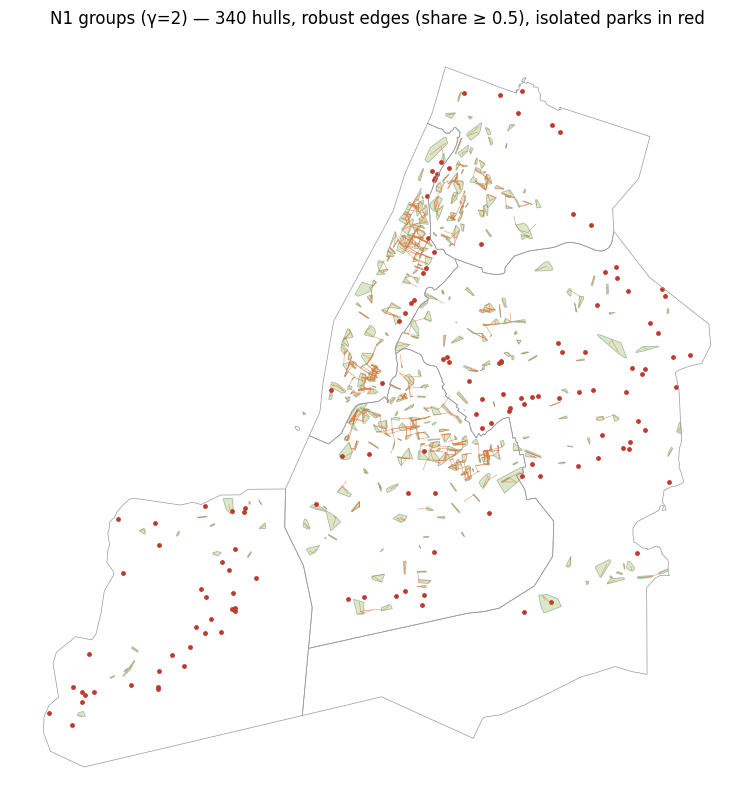

In [9]:
gp = gpd.read_file(GJ_DIR / "groups_N1_g2.geojson").to_crs(CRS)
ed = gpd.read_file(GJ_DIR / "edges_N1.geojson").to_crs(CRS)
pk = gpd.read_file(GJ_DIR / "parks_N1_angular_fewturn.geojson").to_crs(CRS)
boroughs = gpd.read_file(NET_DIR / "boundaries.gpkg", layer="boroughs").set_index("borough").loc[AREA_BOROUGHS]
fig, ax = plt.subplots(figsize=(10, 10))
boroughs.boundary.plot(ax=ax, color="#999999", linewidth=0.5)
gp.plot(ax=ax, color="#97BC62", alpha=0.35, edgecolor="#2C5F2D", linewidth=0.6)
ed[ed.share >= 0.5].plot(ax=ax, color="#E07A3F", linewidth=0.4, alpha=0.8)
pk[pk.status == "robust_isolated"].representative_point().plot(ax=ax, color="#C0392B", markersize=6)
ax.set_title(f"N1 groups (γ=2) — {len(gp)} hulls, robust edges (share ≥ 0.5), isolated parks in red")
ax.set_axis_off()
plt.show()